In [1]:
from pathlib import Path
import re

import requests
from typing import List, Tuple
from tqdm import tqdm

import cv2
import numpy as np
import matplotlib.pyplot as plt

## Set directory

In [2]:
DATA_DIR = Path('data/naturalistic_patches/')

MANIFEST_FILE = DATA_DIR / 'manifest.csv'
SRC_IMG_DIR = DATA_DIR / 'src'

## Download source data

Download photographs taken under water in natural habitats of zebrafish. The data is from a Zenodo database ([Hyperspectral natural imaging](https://zenodo.org/communities/hyperspectral-natural-imaging)) by Zimmermann et al.

In [3]:
def download_src_imgs(manifest_file: str | Path, target_dir: str | Path, overwrite: bool=False) -> None:
    manifest = _read_manifest(manifest_file)
    for file_name, url in tqdm(manifest, desc='Downloading src images'):
        _download_file(url, target_dir / file_name, overwrite)

def _read_manifest(manifest_file: str | Path) -> List[Tuple[str, str]]:
    with open(MANIFEST_FILE, 'r') as f:
        lines = f.readlines()
    lines = [
        stripped
        for line in lines[1:] # skip header
        if (stripped := line.strip())
    ]
    
    return [
        tuple(map(str.strip, line.split(',')))
        for line in lines
    ] # List[Tuple(name, url)]

def _download_file(url: str, save_pth: str | Path, overwrite: bool=False) -> None:
    if save_pth.exists() and not overwrite:
        print(f'{save_pth} already exists.')
        return
    
    with requests.get(url) as r:
        r.raise_for_status()
        with open(save_pth, 'wb') as f:
            f.write(r.content)

> **NOTE**
> 
> If the download fails due to a network issue, you could try the following options:
>
> 1. Download the data manually from the urls specified in `./data/naturalistic_patches/manifest.csv`, and place them under `./data/naturalistic_patches/src/`.
> 2. Skip the download and run the remaining code. In this situation the pipeline will only run on `Measurement20.png`, which is already included as a demo data in the repository under `.data/naturalistic_patches/src/`.

In [ ]:
download_src_imgs(MANIFEST_FILE, SRC_IMG_DIR, overwrite=False)

data/naturalistic_patches/src/Measurement1.png already exists.
data/naturalistic_patches/src/Measurement2.png already exists.
data/naturalistic_patches/src/Measurement3.png already exists.
data/naturalistic_patches/src/Measurement4.png already exists.
data/naturalistic_patches/src/Measurement5.png already exists.
data/naturalistic_patches/src/Measurement6.png already exists.
data/naturalistic_patches/src/Measurement7.png already exists.
data/naturalistic_patches/src/Measurement8.png already exists.
data/naturalistic_patches/src/Measurement9.png already exists.
data/naturalistic_patches/src/Measurement10.png already exists.
data/naturalistic_patches/src/Measurement11.png already exists.
data/naturalistic_patches/src/Measurement12.png already exists.
data/naturalistic_patches/src/Measurement13.png already exists.
data/naturalistic_patches/src/Measurement14.png already exists.
data/naturalistic_patches/src/Measurement15.png already exists.
data/naturalistic_patches/src/Measurement16.png a

(np.float64(-0.5), np.float64(980.5), np.float64(980.5), np.float64(-0.5))

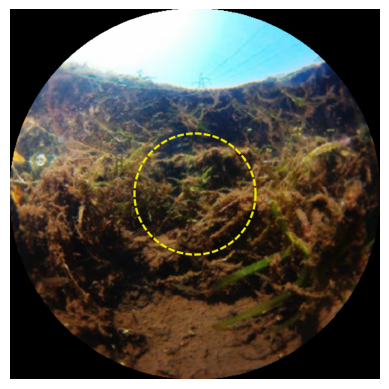

In [5]:
# show example
img = cv2.imread(str(SRC_IMG_DIR / 'Measurement20.png'))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis('off')

## Inpainting

Remove the scan area indicator (dashed circle) from the original photographs before patch extraction.

In [6]:
def inpaint_imgs(
        src_dir: Path,
        dst_dir: Path,
        indicator_rgb: Tuple[int, int, int],
        threshold: int = 240,
        dilation_kernel: int = 3
) -> None:
    dst_dir.mkdir(parents=True, exist_ok=True)
    src_img_pths = list(src_dir.glob("*.png"))
    indicator_bgr = indicator_rgb[::-1] # RGB -> BGR
    for img_pth in tqdm(src_img_pths, desc="Inpainting"):
        src_img = cv2.imread(str(img_pth))
        mask = _create_mask(src_img, indicator_bgr, threshold, dilation_kernel)
        dst_img = cv2.inpaint(src_img, mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)
        cv2.imwrite(str(dst_dir / img_pth.name), dst_img)

def _create_mask(
        bgr_img: np.ndarray,
        indicator_bgr: Tuple[int, int, int],
        threshold: int = 240,
        dilation_kernel: int = 3
) -> np.ndarray:
    color_diff = cv2.absdiff(
        bgr_img,
        (np.ones_like(bgr_img) * indicator_bgr).astype(np.uint8)
    )
    inv_diff = 255 - cv2.cvtColor(color_diff, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(inv_diff, threshold, 255, cv2.THRESH_BINARY)
    # dilation, fully mask out the indicator
    kernel = np.ones((dilation_kernel, dilation_kernel), np.uint8)
    mask = cv2.dilate(mask, kernel, iterations=1)
    return mask

### Script

In [8]:
INPAINTED_IMG_DIR = DATA_DIR / 'inpainted'
INDICATOR_COLOR = (243, 233, 0) # color of the dashed circle

inpaint_imgs(SRC_IMG_DIR, INPAINTED_IMG_DIR, INDICATOR_COLOR)

Inpainting: 100%|██████████| 31/31 [00:02<00:00, 13.82it/s]


### Example

Text(0.5, 1.0, 'Inpainted')

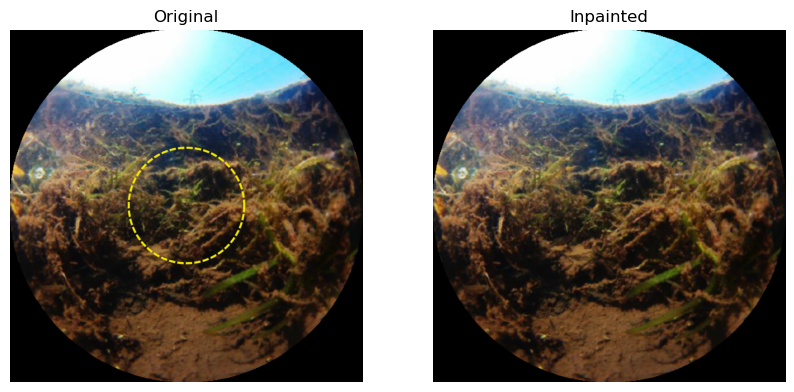

In [9]:
# example
img1 = cv2.imread(str(SRC_IMG_DIR / 'Measurement20.png'))
img2 = cv2.imread(str(INPAINTED_IMG_DIR / 'Measurement20.png'))

fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121)
ax1.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
ax1.axis('off')
ax1.set_title('Original')

ax2 = fig.add_subplot(122)
ax2.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
ax2.axis('off')
ax2.set_title('Inpainted')

## Stereographic remapping

Crop patches from each of the images. Patches are remapped to mitigate the fisheye distortion.

In [10]:
def remap(
    src_img: np.ndarray,
    map_x: np.ndarray,
    map_y: np.ndarray,
    interpolation: int = cv2.INTER_LINEAR,
    border_mode: int = cv2.BORDER_CONSTANT,
    border_value=0,
) -> np.ndarray:
    return cv2.remap(
        src_img, map_x, map_y,
        interpolation=interpolation,
        borderMode=border_mode,
        borderValue=border_value,
    )


def get_remap_uv(
    src_size: Tuple[int, int],
    new_center: Tuple[float, float],
    fov_new: Tuple[float, float],
    dst_size: Tuple[int, int],
    src_center: Tuple[float, float] | None = None,
    north_axis: Tuple[float, float, float] = (0.0, 1.0, 0.0),
    eps: float = 1e-8,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Source is stereographic image of the front hemisphere (full FOV = 180 deg).
    Infer src_scale from H,W by assuming the inscribed circle radius maps to 90 deg.
    fov_new is central-angle FOV in degrees (full width/height).
    """
    src_w, src_h = src_size
    dst_w, dst_h = dst_size

    if src_center is None:
        cx = (src_w - 1) * 0.5
        cy = (src_h - 1) * 0.5
    else:
        cx, cy = src_center

    # Hemisphere assumption:
    # r_plane = 2*tan(90deg/2)=2, r_px = min(W,H)/2
    r_px = min(src_w, src_h) * 0.5
    src_scale = 1.0 / max(r_px, eps)   # plane units per pixel

    # new_center pixel -> plane -> sphere
    u0, v0 = new_center
    X0 = (u0 - cx) * src_scale
    Y0 = -(v0 - cy) * src_scale
    p = _plane_to_sphere(np.array([[X0, Y0]], dtype=np.float64))[0]

    # local zero-twist basis at p: east, north, up
    u = p / max(np.linalg.norm(p), eps)
    z = np.array(north_axis, dtype=np.float64)
    z = z / max(np.linalg.norm(z), eps)

    e = np.cross(z, u)
    ne = np.linalg.norm(e)
    if ne < 1e-6:
        ref = np.array([1.0, 0.0, 0.0], dtype=np.float64)
        if abs(np.dot(ref, u)) > 0.9:
            ref = np.array([0.0, 1.0, 0.0], dtype=np.float64)
        e = np.cross(ref, u)
        ne = max(np.linalg.norm(e), eps)
    e /= ne

    n = np.cross(u, e)
    n /= max(np.linalg.norm(n), eps)

    # dst grid -> (theta_x, theta_y) in radians
    fov_x, fov_y = fov_new
    theta_x_max = np.deg2rad(fov_x * 0.5)
    theta_y_max = np.deg2rad(fov_y * 0.5)

    xs = (np.arange(dst_w, dtype=np.float64) + 0.5) / dst_w
    ys = (np.arange(dst_h, dtype=np.float64) + 0.5) / dst_h
    theta_x = -(xs * 2.0 - 1.0) * theta_x_max
    theta_y = -(ys * 2.0 - 1.0) * theta_y_max
    TX, TY = np.meshgrid(theta_x, theta_y)  # (H,W)

    # exp map on sphere
    t = (TX[..., None] * e[None, None, :] + TY[..., None] * n[None, None, :])
    a = np.linalg.norm(t, axis=2)
    t_hat = t / (a[..., None] + eps)
    q = np.cos(a)[..., None] * u[None, None, :] + np.sin(a)[..., None] * t_hat

    # sphere -> plane -> src pixel coords
    XY = _sphere_to_plane(q.reshape(-1, 3))
    X = XY[:, 0].reshape(dst_h, dst_w)
    Y = XY[:, 1].reshape(dst_h, dst_w)

    map_x = (X / src_scale + cx).astype(np.float32)
    map_y = (-Y / src_scale + cy).astype(np.float32)
    return map_x, map_y


def _plane_to_sphere(XY: np.ndarray, *, eps: float = 1e-12) -> np.ndarray:
    X = XY[:, 0]
    Y = XY[:, 1]
    r2 = X * X + Y * Y
    den = r2 + 1.0
    x = 2.0 * X / (den + eps)
    y = 2.0 * Y / (den + eps)
    z = (r2 - 1.0) / (den + eps)
    return np.stack([x, y, z], axis=1)


def _sphere_to_plane(XYZ: np.ndarray, *, eps: float = 1e-12) -> np.ndarray:
    x = XYZ[:, 0]
    y = XYZ[:, 1]
    z = XYZ[:, 2]
    den = 1.0 - z
    X = x / (den + eps)
    Y = y / (den + eps)
    return np.stack([X, Y], axis=1)

def visualize_remap_points(img, map_x, map_y, step=10):
    vis = img.copy()
    h, w = map_x.shape

    for y in range(0, h, step):
        for x in range(0, w, step):
            u = int(map_x[y, x])
            v = int(map_y[y, x])

            if 0 <= u < img.shape[1] and 0 <= v < img.shape[0]:
                cv2.circle(vis, (u, v), 2, (255, 255, 0), -1)

    return vis

### Script

In [11]:
PATCHED_IMG_DIR = DATA_DIR / 'patched'

SRC_SIZE = (981, 981)
DST_SIZE = (224, 224)
PATCH_FOV = (40, 40)

patch_centers = np.array([
    [310, 250], [490, 260], [670, 250],
    [200, 490], [490, 490], [780, 490],
    [250, 680], [490, 660], [730, 680],
    [490, 825]
]) # crop 10 patches from each image

In [12]:
# helper: extract img id from filename
pattern = re.compile(r'Measurement(\d+).png')
def _extract_id(filename):
    return int(pattern.match(filename).group(1))

# mkdir for patches
PATCHED_IMG_DIR.mkdir(parents=True, exist_ok=True)

# iterate over all images
files = list(INPAINTED_IMG_DIR.glob('*.png'))
for file in tqdm(files):
    img = cv2.imread(str(file))
    img_id = _extract_id(file.name)
    for patch_id, patch_center in enumerate(patch_centers, 1):
        map_x, map_y = get_remap_uv(
            src_size=SRC_SIZE, new_center=patch_center,
            fov_new=PATCH_FOV, dst_size=DST_SIZE
        )
        patch = remap(img, map_x, map_y)
        patch_gray = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)
        cv2.imwrite(str(PATCHED_IMG_DIR / f'{img_id:02d}_{patch_id:02d}.png'), patch_gray)

100%|██████████| 31/31 [00:02<00:00, 12.47it/s]


### Example

Text(0.5, 1.0, 'Remapped patch (grayscale)')

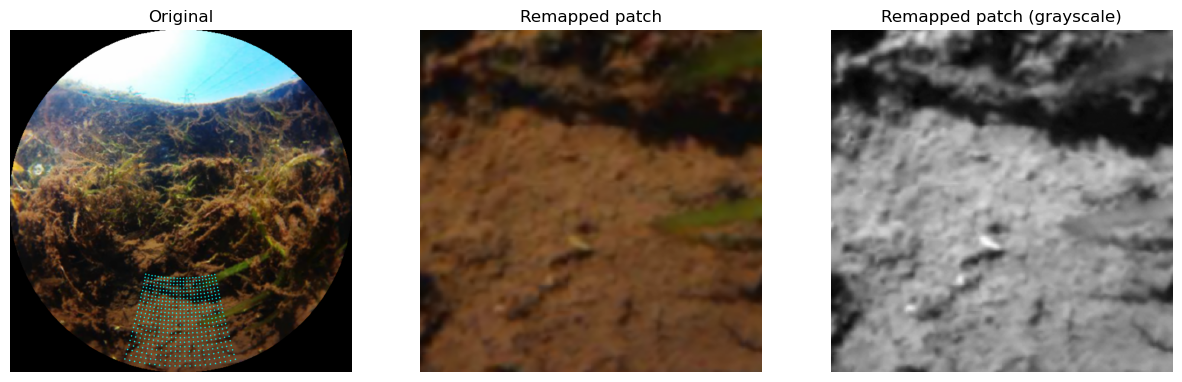

In [13]:
# example
img = cv2.imread(str(INPAINTED_IMG_DIR / 'Measurement20.png'))

map_x, map_y = get_remap_uv(
    src_size=SRC_SIZE, new_center=patch_centers[9],
    fov_new=PATCH_FOV, dst_size=DST_SIZE
)

vis = visualize_remap_points(img, map_x, map_y)
patch = remap(img, map_x, map_y)
patch_gray = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)

fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131)
ax1.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
ax1.axis('off')
ax1.set_title('Original')

ax2 = fig.add_subplot(132)
ax2.imshow(cv2.cvtColor(patch, cv2.COLOR_BGR2RGB))
ax2.axis('off')
ax2.set_title('Remapped patch')

ax3 = fig.add_subplot(133)
ax3.imshow(patch_gray, cmap='gray')
ax3.axis('off')
ax3.set_title('Remapped patch (grayscale)')

## 

## Brightness adjustment

Remap brightness to reduce luminance variability across patches.

In [14]:
sigmoid = lambda x: 1 / (1 + np.exp(-x))

def adjust_brightness(
        img: np.ndarray,
        percentile_coverage: Tuple[int, int],
        dst_brightness_range: Tuple[int, int] = (0, 255),
        tau: float = 0.15
):
    src_brightness_max = np.percentile(img, percentile_coverage[1])
    src_brightness_min = np.percentile(img, percentile_coverage[0])
    src_brightness_mean = np.mean(img)

    scale = max(src_brightness_max - src_brightness_mean, src_brightness_mean - src_brightness_min)
    normed = (img.astype(np.float32) - src_brightness_mean) / scale
    
    dst_brightness_min, dst_brightness_max = dst_brightness_range
    img_adj = sigmoid(normed / tau) * (dst_brightness_max - dst_brightness_min) + dst_brightness_min
    img_adj = np.clip(img_adj, 0, 255).astype(np.uint8)
    return img_adj

### Script

In [15]:
OUTPUT_DIR = DATA_DIR / 'output'

# brightness mapping params
PERCENTILE_COVERAGE = (10, 90) # dynamic range (in percentiles)
DST_BRIGHTNESS_RANGE = (0, 255)
TAU = 0.15 # scaling factor for sigmoid, adjust it according to your projector


In [16]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

files = list(PATCHED_IMG_DIR.glob('*.png'))
for file in tqdm(files):
    img = cv2.imread(str(file))
    img_adj = adjust_brightness(img, PERCENTILE_COVERAGE, DST_BRIGHTNESS_RANGE, TAU)
    cv2.imwrite(str(OUTPUT_DIR / file.name), img_adj)

100%|██████████| 310/310 [00:01<00:00, 210.88it/s]


### Example

Text(0.5, 1.0, 'Brightness remapped')

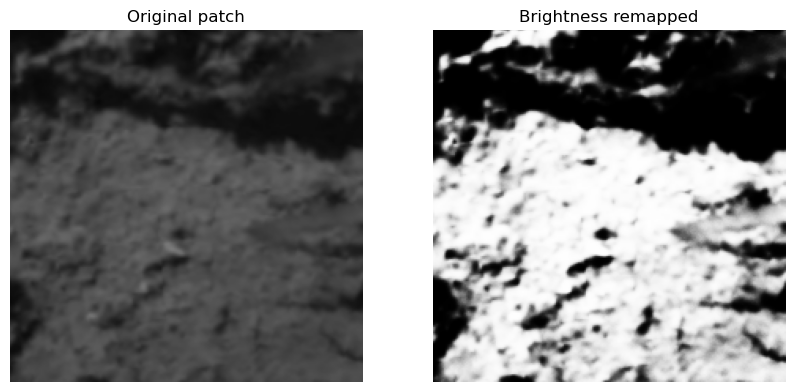

In [17]:
# example
eg_name = '20_10.png'
img1 = cv2.imread(str(PATCHED_IMG_DIR / eg_name))
img2 = cv2.imread(str(OUTPUT_DIR / eg_name))

fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121)
ax1.imshow(img1)
ax1.axis('off')
ax1.set_title('Original patch')

ax2 = fig.add_subplot(122)
ax2.imshow(img2)
ax2.axis('off')
ax2.set_title('Brightness remapped')